## Chuẩn bị dữ liệu 

In [18]:
import cv2 
import matplotlib.pyplot as plt
import numpy as np
import pywt 

In [19]:
def display_images(*images, titles=None, max_cols=5):
    num_images = min(len(images), 12)  # Giới hạn tối đa 10 ảnh
    
    if num_images == 0:
        print("No images to display.")
        return
    
    # Tính toán số hàng và cột
    cols = min(num_images, max_cols)
    rows = (num_images + cols - 1) // cols
    
    # Tạo figure
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    
    # Ép kiểu axes thành mảng 1 chiều để dễ truy vấn trong vòng lặp
    if num_images == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
        
    for i in range(num_images):
        img = images[i]
        
        # Kiểm tra nếu là ảnh xám (2D) hoặc ảnh màu (3D)
        if len(img.shape) == 2:
            axes[i].imshow(img, cmap='gray')
        else:
            axes[i].imshow(img)
            
        # Thiết lập tiêu đề
        title = titles[i] if titles and i < len(titles) else f"Image {i+1}"
        axes[i].set_title(title)
        axes[i].axis('off')
    
    # Ẩn các ô subplot dư thừa nếu có
    for i in range(num_images, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

In [25]:
#ảnh giống nhau 
img_a = "/home/tuong/Courses/CV/Chap3/data/flower1_noise_0.1.jpg"
img_b = "/home/tuong/Courses/CV/Chap3/data_backup/flower2.jpg"

In [33]:
def process_img(img):

    img = cv2.imread(img, 0)

    #resize 
    img_rs = cv2.resize(img, (128, 128))

    # DWT
    coffs = pywt.dwt2(img_rs, 'haar')
    img_ll = coffs[0]

    #feature extraction
    feature_img = img_ll.flatten()
    
    #display 
    display_images(img_rs, img_ll, titles=['Resized Image', 'LL'])


    #normalize bằng 1 bit 
    feature_img = feature_img / np.max(feature_img)  # Chuẩn hóa về khoảng [0, 1]
    feature_img = (feature_img > 0.5).astype(np.uint8)

    return feature_img

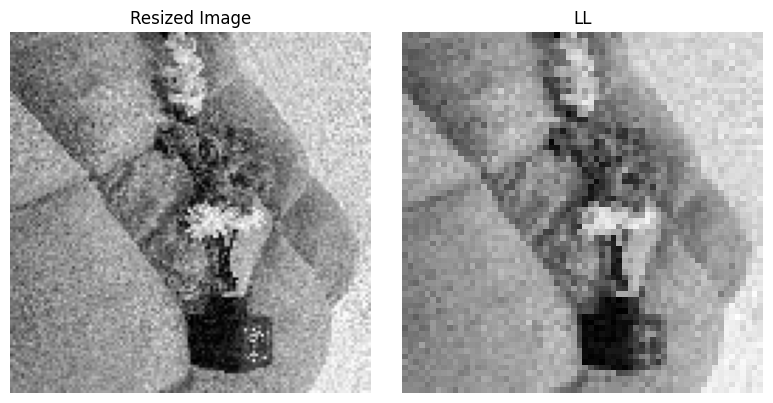

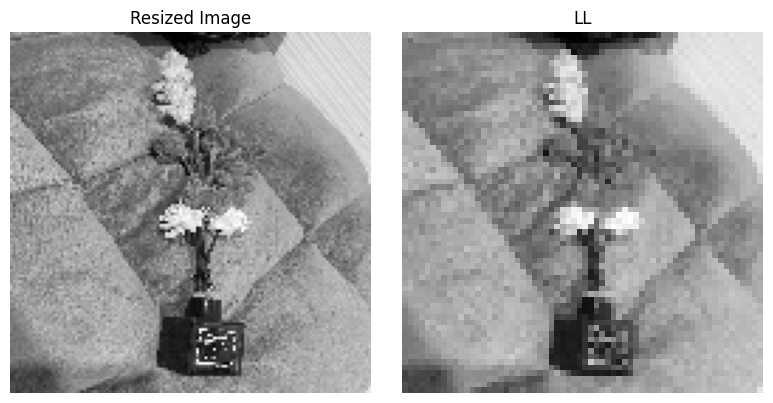

array([1, 1, 1, ..., 1, 1, 1], shape=(4096,), dtype=uint8)

In [34]:
process_img(img_a)
process_img(img_b)